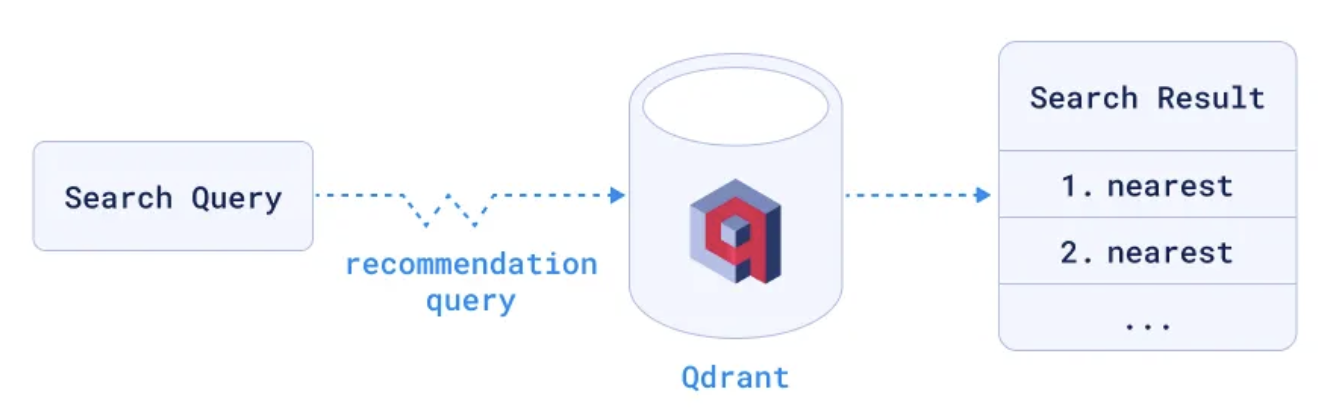

# Qdrant 설치 확인 

## Qdrant 클라이언트 연결 테스트 

In [ ]:
from qdrant_client import QdrantClient

client = QdrantClient(host="localhost", port=6333)

# Qdrant Cloud 연결
# client = QdrantClient(
#     url="https://your-cluster.qdrant.io",
#     api_key="your-api-key"
# )

print("Qdrant 클라이언트 연결 완료")

## [Qdrant 접속](http://localhost:6333/dashboard#/welcome) 
```url
http://localhost:6333/dashboard#/welcome
```

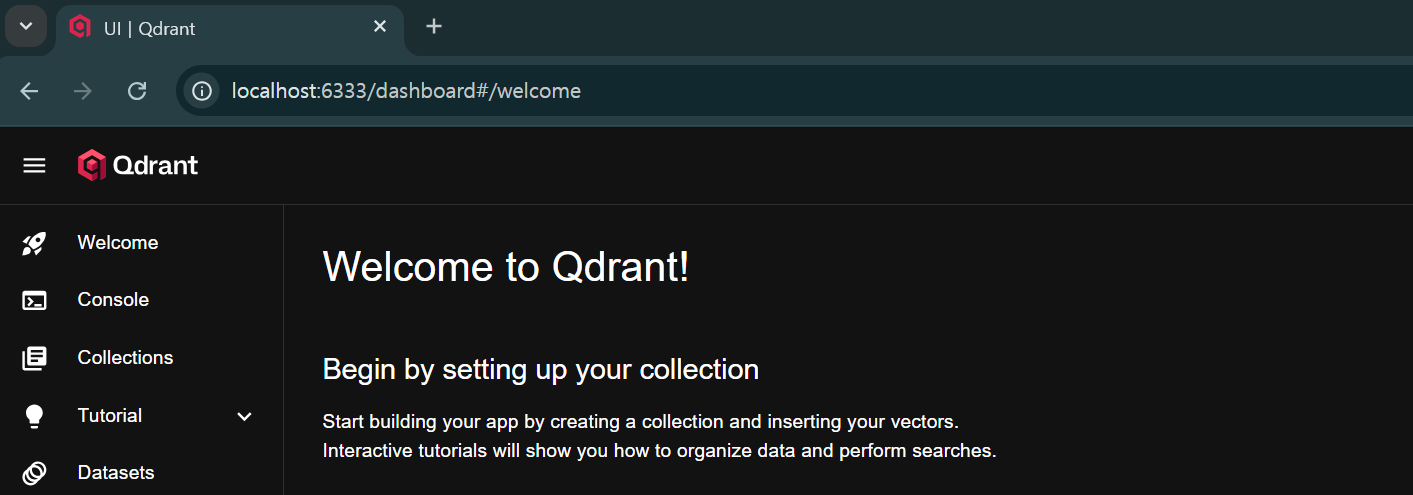

# VectorDB에 데이터 추가하기 

## Loader

In [ ]:
from glob import glob

files = glob("./data/*.txt")

print(f"전체 txt 파일의 수: {len(files)}")


In [ ]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import TextLoader

loader = DirectoryLoader("./data", glob="*.txt", show_progress=True,
                         loader_cls=TextLoader, loader_kwargs={"encoding": "utf-8"})

docs = loader.load()
print(f"로드된 파일의 수: {len(docs)}")

## Splitter

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300, chunk_overlap=30)
    

In [ ]:
docs_by_splitter = text_splitter.split_documents(docs)
print(f"분리된 문서의 수: {len(docs_by_splitter)}")

## Embedding Model

### API Key 등록 
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [Huggingface 토큰 등록](https://huggingface.co/settings/tokens)

In [ ]:
from dotenv import load_dotenv 

load_dotenv()

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

## Qdrant VectorStore

In [ ]:
from langchain_qdrant import QdrantVectorStore

# Qdrant 벡터스토어 생성
vectorstore = QdrantVectorStore.from_documents(
    documents=docs_by_splitter,           # 분할된 문서
    embedding=embeddings_model,       # 임베딩 함수
    location="http://localhost:6333",        # 또는 인메모리 모드(":memory:")
    collection_name="rag_keywords",  # 컬렉션 이름
)

print("Qdrant 벡터스토어 생성 완료")

### 저장된 데이터 확인

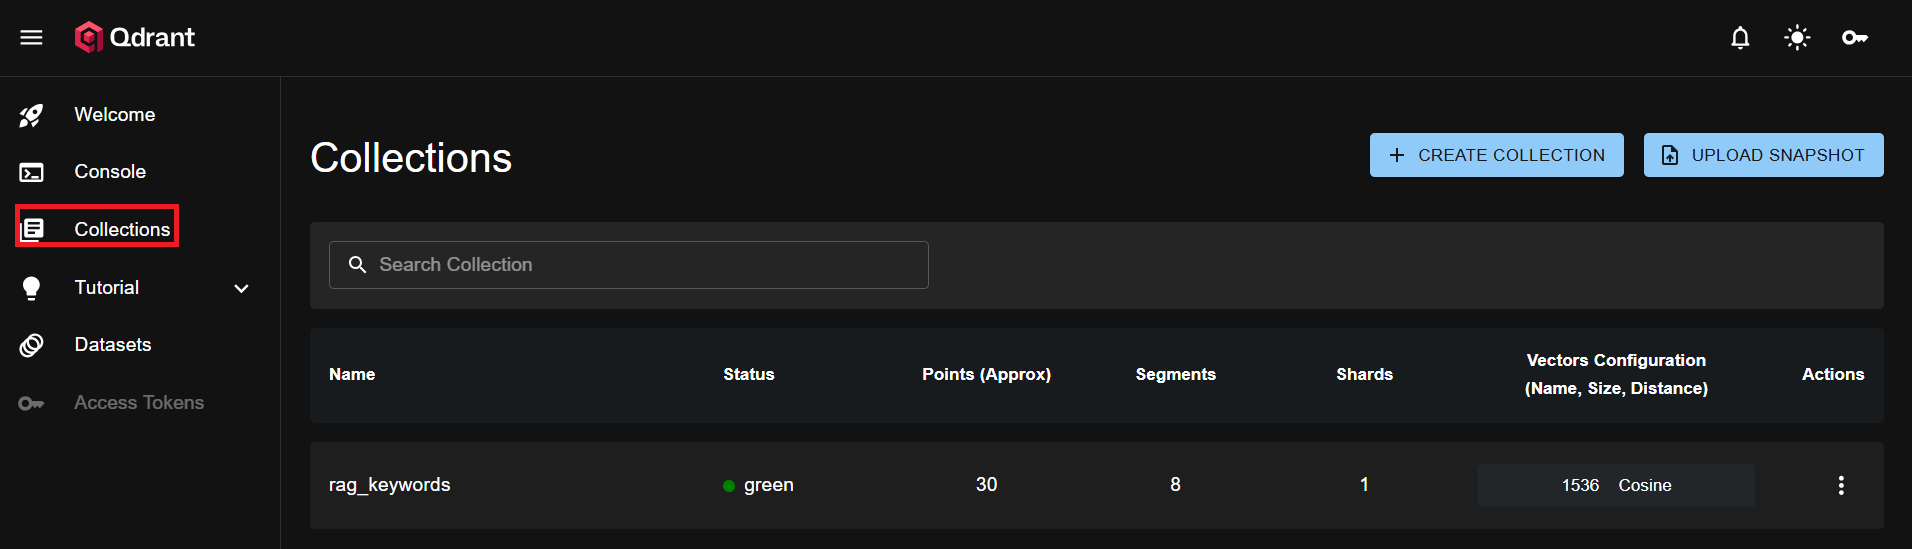

### 조회 테스트

In [ ]:
results = vectorstore.similarity_search("TF IDF 에 대하여 알려줘", k=3)

for i, doc in enumerate(results, 1):
    print(f"{i}. {doc.page_content}")
    print(f"   메타데이터: {doc.metadata}")
    print()